<a href="https://colab.research.google.com/github/khoirul2003/PVCK_Ganjil_2025/blob/main/Weeb10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


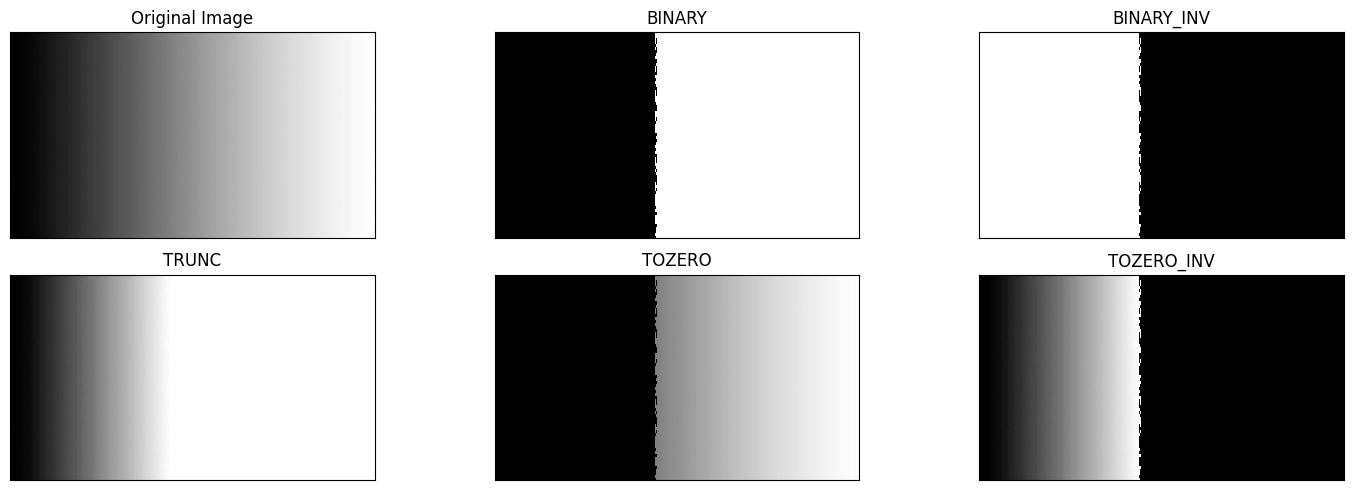

In [2]:
import cv2 as cv
from google.colab.patches import cv2_imshow
import numpy as np
import matplotlib.pyplot as plt

# Path gambar
filename = '/content/drive/MyDrive/Images/gradient.jpg'
img = cv.imread(filename, 0)  # Pastikan gambar dibaca dalam mode grayscale

# Nilai threshold yang ditentukan
thresh = 127

# 1. THRESH_BINARY: jika pixel > thresh, maka 255, selain itu 0
ret, thresh1 = cv.threshold(img, thresh, 255, cv.THRESH_BINARY)

# 2. THRESH_BINARY_INV: kebalikan dari THRESH_BINARY
ret, thresh2 = cv.threshold(img, thresh, 255, cv.THRESH_BINARY_INV)

# 3. THRESH_TRUNC: jika pixel > thresh, maka pixel = thresh
ret, thresh3 = cv.threshold(img, thresh, 255, cv.THRESH_TRUNC)

# 4. THRESH_TOZERO: jika pixel <= thresh, maka pixel = 0
ret, thresh4 = cv.threshold(img, thresh, 255, cv.THRESH_TOZERO)

# 5. THRESH_TOZERO_INV: jika pixel > thresh, maka pixel = 0
ret, thresh5 = cv.threshold(img, thresh, 255, cv.THRESH_TOZERO_INV)

# Judul dan gambar untuk ditampilkan
titles = ['Original Image', 'BINARY', 'BINARY_INV', 'TRUNC', 'TOZERO', 'TOZERO_INV']
images = [img, thresh1, thresh2, thresh3, thresh4, thresh5]

# Tampilkan hasil thresholding
plt.figure(figsize=(15, 5))
for i in range(len(images)):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i], cmap='gray', interpolation='nearest')
    plt.title(titles[i])
    plt.xticks([]), plt.yticks([])
plt.tight_layout()
plt.show()

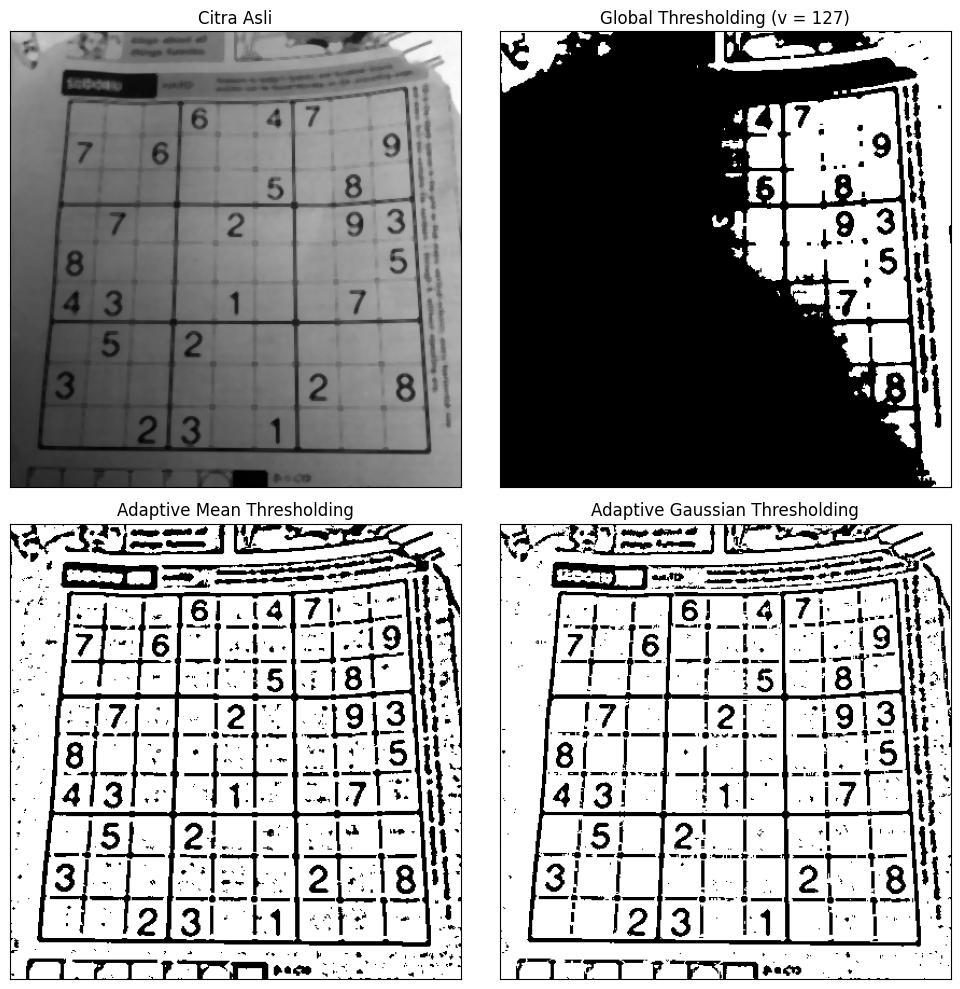

In [3]:
import cv2 as cv
import matplotlib.pyplot as plt

filename = '/content/drive/MyDrive/Images/sudoku-original.jpg'

# Preprocessing: median blur untuk mengurangi noise
citra = cv.medianBlur(cv.imread(filename), 5)

# Konversi ke grayscale
gray = cv.cvtColor(citra, cv.COLOR_BGR2GRAY)

# Threshold global
thresh = 127
ret, th1 = cv.threshold(gray, thresh, 255, cv.THRESH_BINARY)

# Threshold adaptif: Mean dan Gaussian
th2 = cv.adaptiveThreshold(gray, 255, cv.ADAPTIVE_THRESH_MEAN_C, cv.THRESH_BINARY, 11, 2)
th3 = cv.adaptiveThreshold(gray, 255, cv.ADAPTIVE_THRESH_GAUSSIAN_C, cv.THRESH_BINARY, 11, 2)

# Judul dan citra untuk ditampilkan
titles = [
    'Citra Asli',
    'Global Thresholding (v = 127)',
    'Adaptive Mean Thresholding',
    'Adaptive Gaussian Thresholding'
]
citra2 = [gray, th1, th2, th3]

# Plot hasil thresholding
plt.figure(figsize=(10, 10))
for i in range(len(citra2)):
    plt.subplot(2, 2, i + 1)
    plt.imshow(citra2[i], cmap='gray')
    plt.title(titles[i])
    plt.xticks([]), plt.yticks([])
plt.tight_layout()
plt.show()


/tmp/ipython-input-1853420245.py:30: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(blur.ravel(), 256, [50, 200])


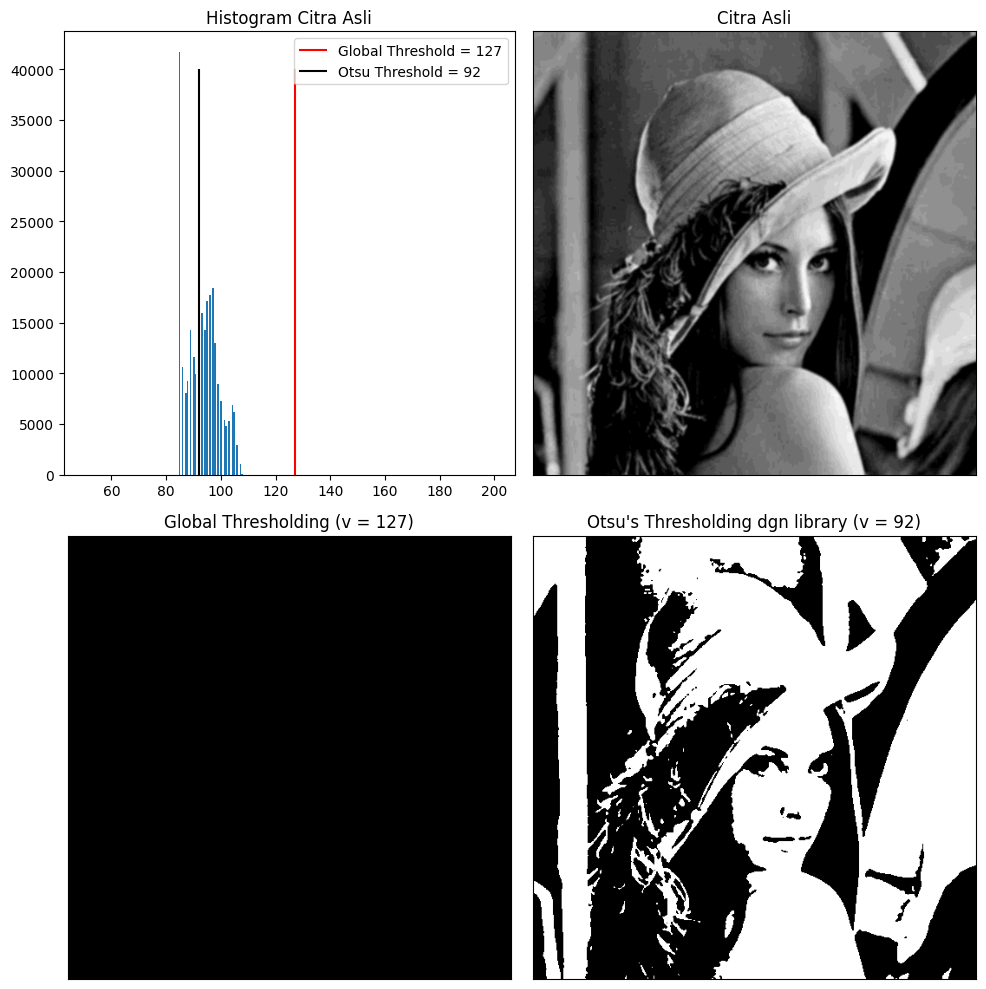

In [4]:
import cv2 as cv
import matplotlib.pyplot as plt

# Path ke citra
filename = '/content/drive/MyDrive/Images/lena_gs_lc2.jpg'

# Baca citra dalam mode grayscale
img = cv.imread(filename, 0)

# Gaussian blur untuk mengurangi noise
blur = cv.GaussianBlur(img, (5, 5), 0)

# Threshold global
thresh = 127
ret, th1 = cv.threshold(blur, thresh, 255, cv.THRESH_BINARY)

# Threshold Otsu
ret2, th2 = cv.threshold(blur, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)

# Judul untuk masing-masing citra
otsu_title = f"Otsu's Thresholding dgn library (v = {ret2:.0f})"
titles = ['Citra Asli', 'Global Thresholding (v = 127)', otsu_title]
citra3 = [blur, th1, th2]

# Plot histogram dan hasil thresholding
plt.figure(figsize=(10, 10))

# Histogram citra blur
plt.subplot(2, 2, 1)
plt.hist(blur.ravel(), 256, [50, 200])
plt.vlines(ret, 0, 40000, colors='red', label='Global Threshold = 127')
plt.vlines(ret2, 0, 40000, colors='black', label=f"Otsu Threshold = {ret2:.0f}")
plt.title('Histogram Citra Asli')
plt.legend()

# Tampilkan citra hasil thresholding
for i in range(len(citra3)):
    plt.subplot(2, 2, i + 2)
    plt.imshow(citra3[i], cmap='gray')
    plt.title(titles[i])
    plt.xticks([]), plt.yticks([])

plt.tight_layout()
plt.show()

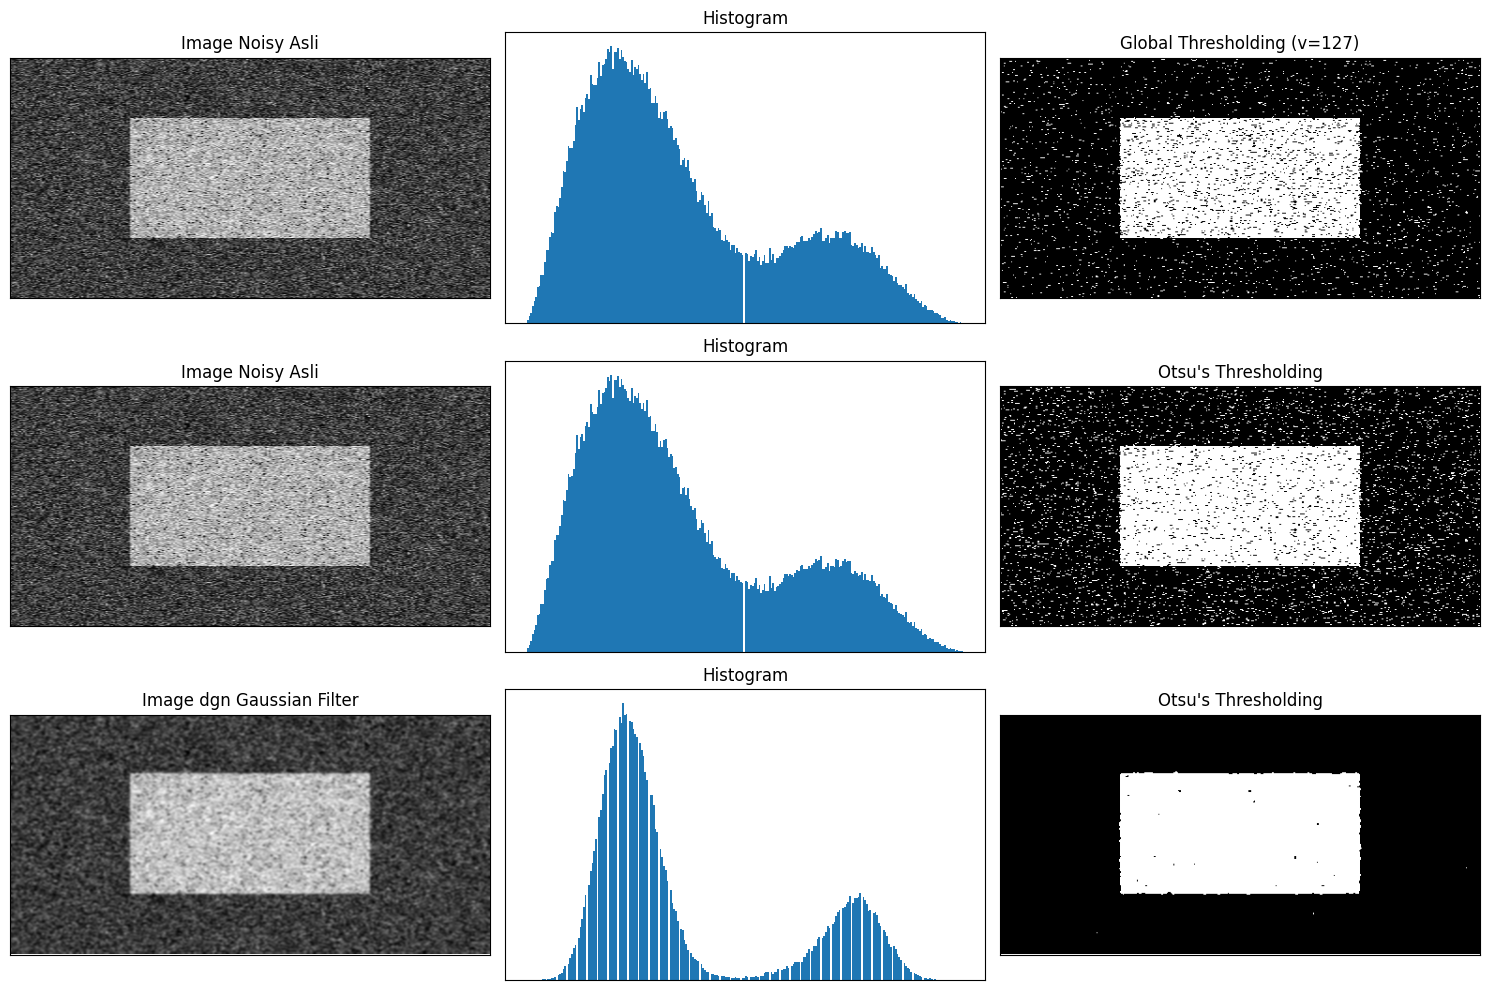

In [7]:
import cv2 as cv
import matplotlib.pyplot as plt

# Path ke citra noisy
filename = '/content/drive/MyDrive/Images/noisy2.png'
img = cv.imread(filename, 0)

# Global Thresholding
ret1, th1 = cv.threshold(img, 127, 255, cv.THRESH_BINARY)

# Otsu's Thresholding
ret2, th2 = cv.threshold(img, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)

# Gaussian Filtering + Otsu's Thresholding
blur = cv.GaussianBlur(img, (5, 5), 0)
ret3, th3 = cv.threshold(blur, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)

# Kumpulan citra dan judul
images = [img, None, th1,
          img, None, th2,
          blur, None, th3]

titles = [
    'Image Noisy Asli', 'Histogram', 'Global Thresholding (v=127)',
    'Image Noisy Asli', 'Histogram', "Otsu's Thresholding",
    'Image dgn Gaussian Filter', 'Histogram', "Otsu's Thresholding"
]

# Plotting
plt.figure(figsize=(15, 10))
for i in range(3):
    # Tampilkan citra asli atau hasil filter
    plt.subplot(3, 3, i * 3 + 1)
    plt.imshow(images[i * 3], cmap='gray')
    plt.title(titles[i * 3])
    plt.xticks([]), plt.yticks([])

    # Tampilkan histogram
    plt.subplot(3, 3, i * 3 + 2)
    plt.hist(images[i * 3].ravel(), 256)
    plt.title(titles[i * 3 + 1])
    plt.xticks([]), plt.yticks([])

    # Tampilkan hasil thresholding
    plt.subplot(3, 3, i * 3 + 3)
    plt.imshow(images[i * 3 + 2], cmap='gray')
    plt.title(titles[i * 3 + 2])
    plt.xticks([]), plt.yticks([])

plt.tight_layout()
plt.show()

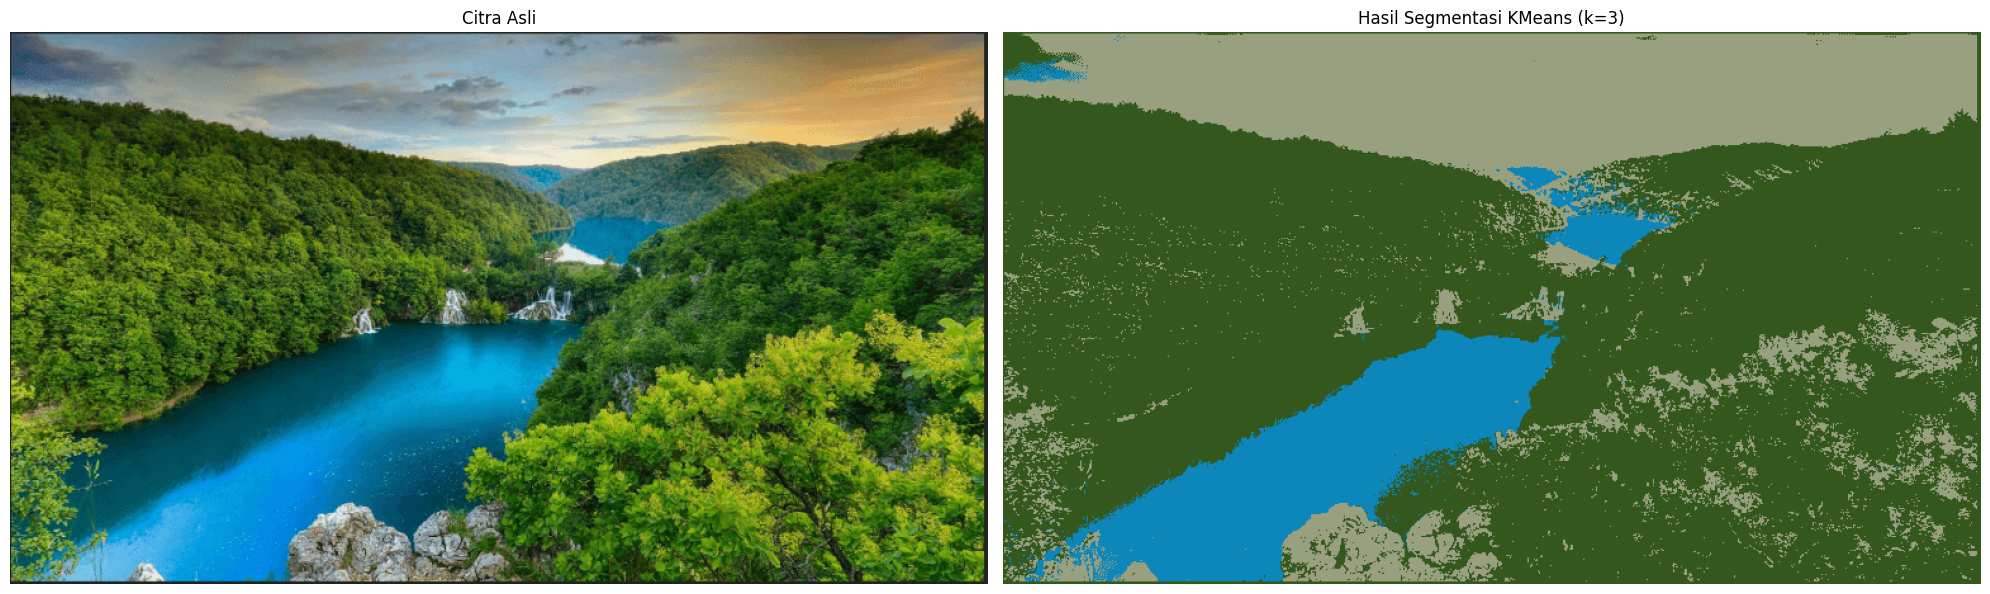

In [8]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Path ke citra
filename = '/content/drive/MyDrive/Images/jungle.png'

# Baca citra dan konversi ke RGB
img = cv.imread(filename)
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Ubah citra menjadi array 2D (flattening)
pixel_values = img.reshape((-1, 3))
pixel_values = np.float32(pixel_values)

# Kriteria berhenti: maksimal 100 iterasi atau perubahan centroid < 0.2
criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 100, 0.2)

# Jumlah cluster (warna dominan)
k = 3
_, labels, centers = cv.kmeans(pixel_values, k, None, criteria, 10, cv.KMEANS_RANDOM_CENTERS)

# Konversi centroid ke tipe uint8
centers = np.uint8(centers)

# Flatten label dan buat citra hasil segmentasi
labels = labels.flatten()
segmented_image = centers[labels]
segmented_image = segmented_image.reshape(img.shape)

# Tampilkan citra asli dan hasil segmentasi
plt.figure(figsize=(20, 20))
plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title('Citra Asli')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(segmented_image)
plt.title('Hasil Segmentasi KMeans (k=3)')
plt.axis('off')

plt.tight_layout()
plt.show()

[[ 13 134 185]
 [153 160 128]
 [ 52  87  30]]


(<Axes: >, <matplotlib.image.AxesImage at 0x7afb91d29070>)

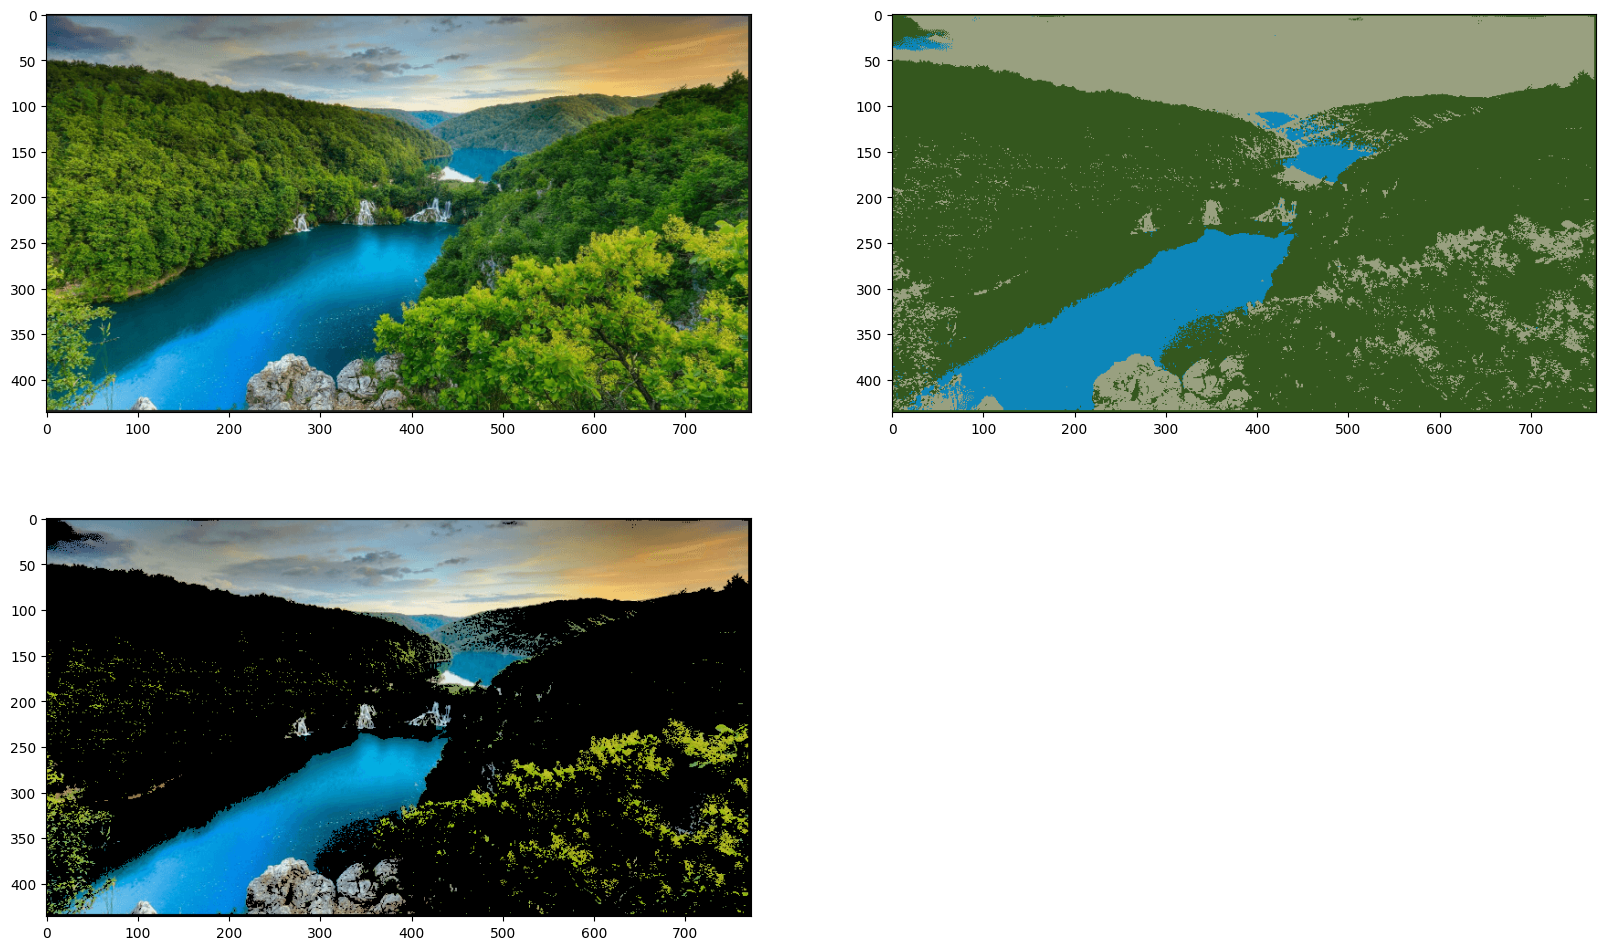

In [26]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

filename = '/content/drive/MyDrive/Images/jungle.png'
img = cv.imread(filename)
img = cv.cvtColor(img,cv.COLOR_BGR2RGB)

pixel_values = img.reshape((-1, 3))
pixel_values = np.float32(pixel_values)

criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 100, 0.2)

k = 3
_, labels, centers = cv.kmeans(pixel_values, k, None, criteria, 10, cv.KMEANS_RANDOM_CENTERS)

centers = np.uint8(centers)
labels = labels.flatten()

print(centers)

segmented_image = centers[labels.flatten()]
segmented_image = segmented_image.reshape(img.shape)

masked_image = np.copy(img)
masked_image = masked_image.reshape((-1, 3))

cluster = 2
masked_image[labels == cluster] = [0, 0, 0]
masked_image = masked_image.reshape(img.shape)

plt.figure(figsize = (20,12))
plt.subplot(2,2,1),plt.imshow(img)
plt.subplot(2,2,2),plt.imshow(segmented_image)
plt.subplot(2,2,3),plt.imshow(masked_image)

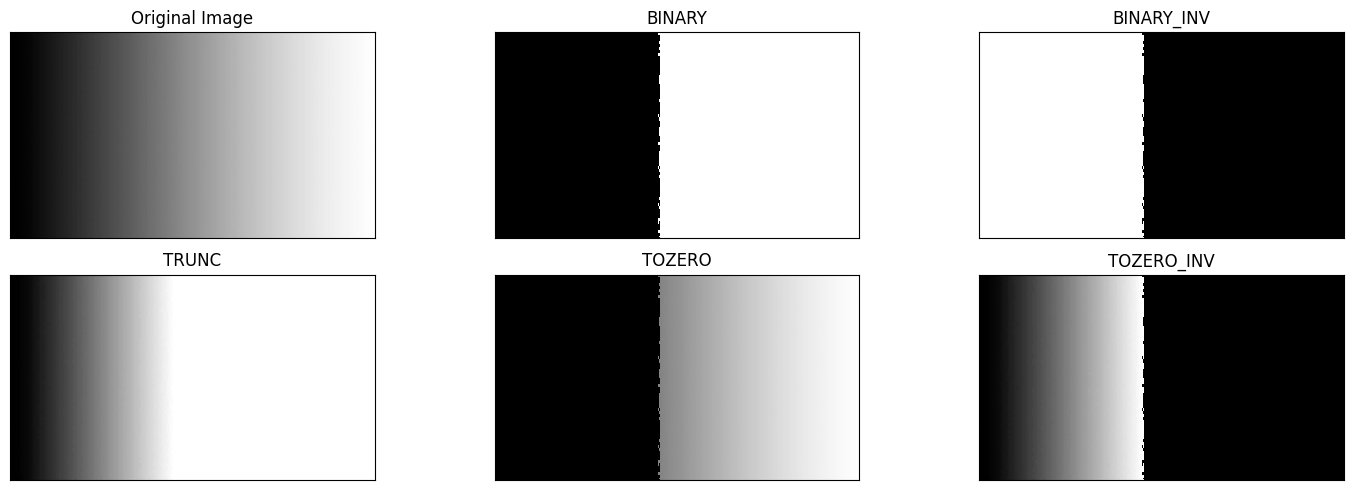

In [30]:
import cv2 as cv
from google.colab.patches import cv2_imshow
import numpy as np
import matplotlib.pyplot as plt

# Path gambar
filename = '/content/drive/MyDrive/Images/gradient.jpg'
img = cv.imread(filename, 0)  # Pastikan gambar dibaca dalam mode grayscale

# Nilai threshold yang ditentukan
thresh = 130

# 1. THRESH_BINARY: jika pixel > thresh, maka 255, selain itu 0
ret, thresh1 = cv.threshold(img, thresh, 255, cv.THRESH_BINARY)

# 2. THRESH_BINARY_INV: kebalikan dari THRESH_BINARY
ret, thresh2 = cv.threshold(img, thresh, 255, cv.THRESH_BINARY_INV)

# 3. THRESH_TRUNC: jika pixel > thresh, maka pixel = thresh
ret, thresh3 = cv.threshold(img, thresh, 255, cv.THRESH_TRUNC)

# 4. THRESH_TOZERO: jika pixel <= thresh, maka pixel = 0
ret, thresh4 = cv.threshold(img, thresh, 255, cv.THRESH_TOZERO)

# 5. THRESH_TOZERO_INV: jika pixel > thresh, maka pixel = 0
ret, thresh5 = cv.threshold(img, thresh, 255, cv.THRESH_TOZERO_INV)

# Judul dan gambar untuk ditampilkan
titles = ['Original Image', 'BINARY', 'BINARY_INV', 'TRUNC', 'TOZERO', 'TOZERO_INV']
images = [img, thresh1, thresh2, thresh3, thresh4, thresh5]

# Tampilkan hasil thresholding
plt.figure(figsize=(15, 5))
for i in range(len(images)):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i], cmap='gray', interpolation='nearest')
    plt.title(titles[i])
    plt.xticks([]), plt.yticks([])
plt.tight_layout()
plt.show()

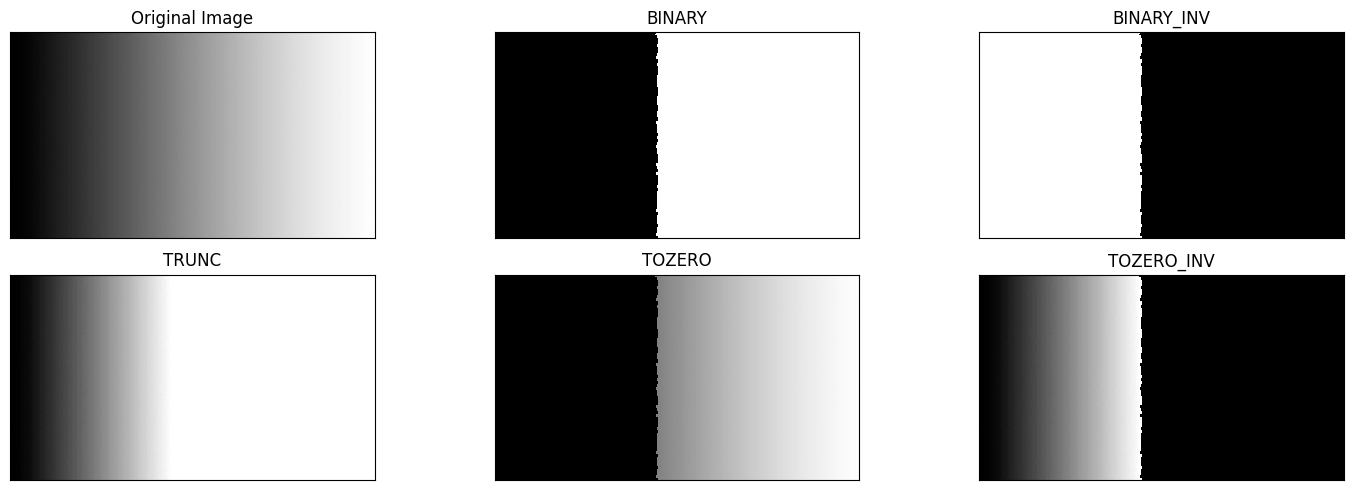

In [35]:
import cv2 as cv
from google.colab.patches import cv2_imshow
import numpy as np
import matplotlib.pyplot as plt

filename = '/content/drive/MyDrive/Images/gradient.jpg'
img = cv.imread(filename, 0)

thresh = 128
maxval = 255

thresh1 = np.zeros_like(img)
thresh1[img > thresh] = maxval

thresh2 = np.full_like(img, maxval)
thresh2[img > thresh] = 0

thresh3 = img.copy()
thresh3[img > thresh] = thresh

thresh4 = img.copy()
thresh4[img <= thresh] = 0

thresh5 = img.copy()
thresh5[img > thresh] = 0

titles = ['Original Image', 'BINARY', 'BINARY_INV', 'TRUNC', 'TOZERO', 'TOZERO_INV']
images = [img, thresh1, thresh2, thresh3, thresh4, thresh5]

plt.figure(figsize=(15, 5))
for i in range(len(images)):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i], cmap='gray', interpolation='nearest')
    plt.title(titles[i])
    plt.xticks([]), plt.yticks([])
plt.tight_layout()
plt.show()

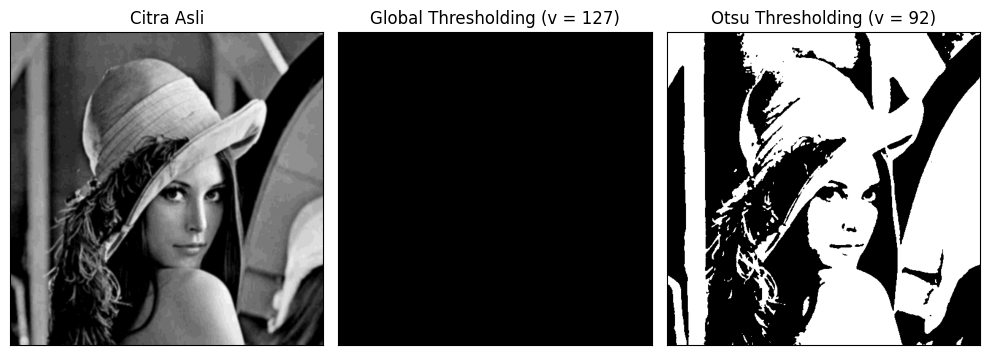

In [43]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

filename = '/content/drive/MyDrive/Images/lena_gs_lc2.jpg'

img = cv.imread(filename, 0)

blur = cv.GaussianBlur(img, (5, 5), 0)
thresh = 127
ret, th1 = cv.threshold(blur, thresh, 255, cv.THRESH_BINARY)
hist = cv.calcHist([blur], [0], None, [256], [0, 256])
hist_norm = hist.ravel() / hist.sum()

i = np.arange(256)
cdf_w = hist_norm.cumsum()
cdf_m = (i * hist_norm).cumsum()
total_mean = cdf_m[-1]
max_variance = 0.0
optimal_thresh = 0

for t in range(1, 255):
    w0 = cdf_w[t]
    w1 = 1.0 - w0

    if w0 == 0 or w1 == 0:
        continue

    mu0 = cdf_m[t] / w0
    mu1 = (total_mean - cdf_m[t]) / w1
    variance = w0 * w1 * (mu0 - mu1)**2

    if variance > max_variance:
        max_variance = variance
        optimal_thresh = t

ret2_manual = optimal_thresh

th2_manual = np.zeros_like(blur)
th2_manual[blur > ret2_manual] = 255

otsu_title = f"Otsu Thresholding (v = {ret2_manual:.0f})"
titles = ['Citra Asli', 'Global Thresholding (v = 127)', otsu_title]
citra3 = [blur, th1, th2_manual]

plt.figure(figsize=(10, 4))

for i in range(len(citra3)):
    plt.subplot(1, 3, i + 1)
    plt.imshow(citra3[i], cmap='gray')
    plt.title(titles[i])
    plt.xticks([]), plt.yticks([])

plt.tight_layout()
plt.show()

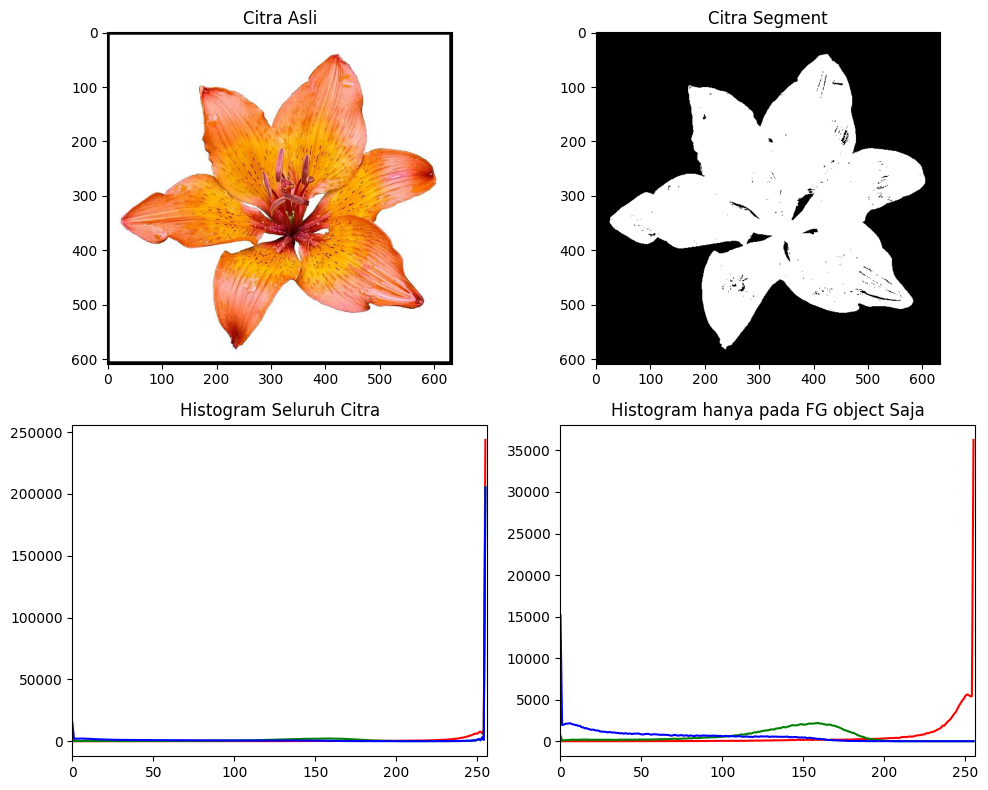

In [54]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

filename = '/content/drive/MyDrive/Images/lily.jpg'
img_color = cv.imread(filename)
img_color = cv.cvtColor(img_color, cv.COLOR_BGR2RGB)
img_gray = cv.cvtColor(img_color, cv.COLOR_RGB2GRAY)

# Segmentasi
_, mask = cv.threshold(img_gray, 0, 255, cv.THRESH_BINARY_INV + cv.THRESH_OTSU)

border_thickness = 5
color_black = [0, 0, 0]

img_with_border = cv.copyMakeBorder(
    img_color, border_thickness, border_thickness, border_thickness, border_thickness,
    cv.BORDER_CONSTANT, value=color_black
)

mask_with_border = cv.copyMakeBorder(
    mask, border_thickness, border_thickness, border_thickness, border_thickness,
    cv.BORDER_CONSTANT, value=0
)

# Histogram
colors = ('r', 'g', 'b')
hist_full, hist_foreground = [], []

for i, col in enumerate(colors):
    h_full = cv.calcHist([img_color], [i], None, [256], [0, 256])
    h_fg = cv.calcHist([img_color], [i], mask, [256], [0, 256])
    hist_full.append(h_full)
    hist_foreground.append(h_fg)

plt.figure(figsize=(10, 8))

plt.subplot(2, 2, 1)
plt.imshow(img_with_border)
plt.title('Citra Asli')

plt.subplot(2, 2, 2)
plt.imshow(mask_with_border, cmap='gray')
plt.title('Citra Segment')

plt.subplot(2, 2, 3)
for i, col in enumerate(colors):
    plt.plot(hist_full[i], color=col)
plt.title('Histogram Seluruh Citra')
plt.xlim([0, 256])

plt.subplot(2, 2, 4)
for i, col in enumerate(colors):
    plt.plot(hist_foreground[i], color=col)
plt.title('Histogram hanya pada FG object Saja')
plt.xlim([0, 256])

plt.tight_layout()
plt.show()


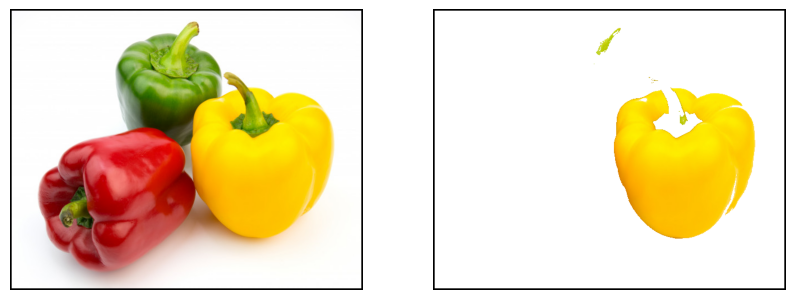

In [66]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Load image
img = cv.imread('/content/drive/MyDrive/Images/peppers.jpg')

# K-Means clustering
pixels = img.reshape(-1, 3).astype(np.float32)
criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 100, 0.2)
_, labels, centers = cv.kmeans(pixels, 8, None, criteria, 10, cv.KMEANS_RANDOM_CENTERS)

# Find yellow cluster
hsv_centers = cv.cvtColor(np.uint8(centers).reshape(1, -1, 3), cv.COLOR_BGR2HSV)[0]
yellow_id = next((i for i, (h, s, v) in enumerate(hsv_centers)
                  if 25 <= h <= 35 and s > 100 and v > 100), -1)

# Create mask and result
mask = (labels.flatten() == yellow_id).reshape(img.shape[:2]).astype(np.uint8) * 255
result = np.where(mask[..., None] == 255, img, 255)

fig, axes = plt.subplots(1, 2, figsize=(10, 6))
for ax, image in zip(axes, [img, result]):
    bordered = cv.copyMakeBorder(image, 3, 3, 3, 3, cv.BORDER_CONSTANT, value=0)
    ax.imshow(cv.cvtColor(bordered, cv.COLOR_BGR2RGB))
    ax.axis('off')
plt.show()

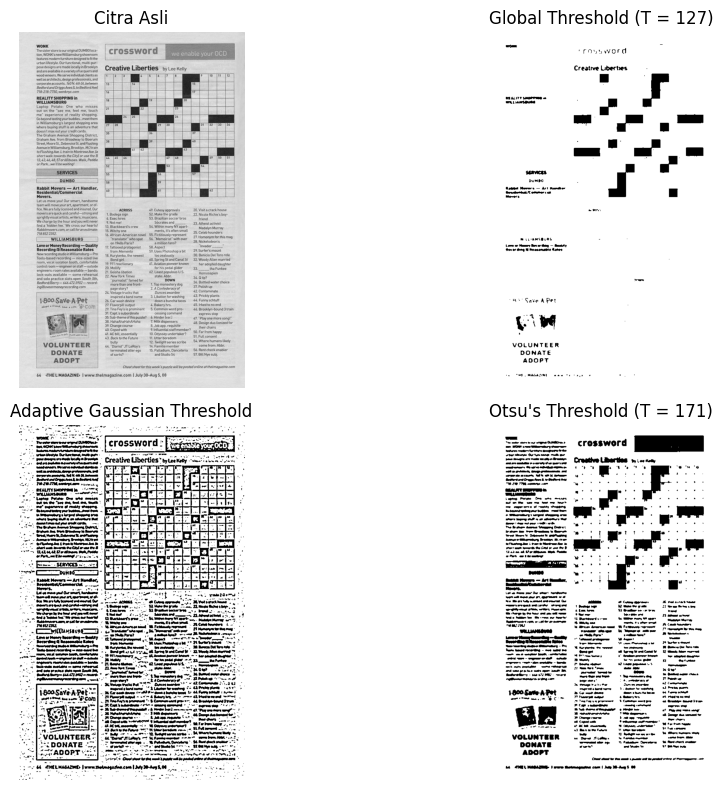

In [71]:
import cv2 as cv
import matplotlib.pyplot as plt

img = cv.imread('/content/drive/MyDrive/Images/crossword.jpg', 0)

blur = cv.GaussianBlur(img, (5,5), 0)

ret1, th_global = cv.threshold(blur, 127, 255, cv.THRESH_BINARY)

th_adaptive = cv.adaptiveThreshold(
    blur, 255, cv.ADAPTIVE_THRESH_GAUSSIAN_C, cv.THRESH_BINARY, 11, 2
)

ret2, th_otsu = cv.threshold(blur, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)

titles = [
    'Citra Asli',
    'Global Threshold (T = 127)',
    'Adaptive Gaussian Threshold',
    f"Otsu's Threshold (T = {ret2:.0f})"
]
images = [img, th_global, th_adaptive, th_otsu]

plt.figure(figsize=(12, 8))
for i in range(4):
    plt.subplot(2, 2, i + 1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()
